# Benchmark Model Training

### Logistic Regression, Random Forest, XGBoost


## Logistic Regression (Mean Rating)


In [4]:
import sys
from pathlib import Path

# Add project root to path
sys.path.append(str(Path("..").resolve()))


from helpers import ModelData
from constants import PROCESSED_DATA_FOLDER
import numpy as np

model_data = ModelData.from_pickle(PROCESSED_DATA_FOLDER / "processed_data.pkl")
model_data

ModelData(n_total=921, n_train=921, n_obs=64887)

In [5]:
# Random Seed für Reproduzierbarkeit
SEED = 42

Index(['business_id', 'density', 'Checkin', 'category', 'chain', 'Price.Level',
       'Restaurant.Size', 'Number.of.Seats', 'ZRI', 'Distance.To.City.Centre',
       'Age', 'is_open', 'Closed', 'VAR', 'MEAN', 'ENTR', 'COUNT', 'ONE_STAR',
       'TWO_STAR', 'THREE_STAR', 'FOUR_STAR', 'FIVE_STAR', 'l_COUNT'],
      dtype='object')

In [6]:
# Aufteilung in business_covariates und rating_stats

# Business covariates (ohne Rating-Statistiken und OHNE Closed!)
business_features = [
    "density",
    "Checkin",
    "category",
    "chain",
    "Price.Level",
    "Restaurant.Size",
    "Number.of.Seats",
    "ZRI",
    "Distance.To.City.Centre",
    "Age",
]

# Rating statistics
rating_features = [
    "VAR",
    "MEAN",
    "ENTR",
    "COUNT",
    "ONE_STAR",
    "TWO_STAR",
    "THREE_STAR",
    "FOUR_STAR",
    "FIVE_STAR",
    "l_COUNT",
]

print(f"Business features: {len(business_features)} Variablen")
print(f"Rating features: {len(rating_features)} Variablen")
print(f"Gesamt: {len(business_features) + len(rating_features)} Variablen")
print("\nWICHTIG: 'Closed' ist die Zielvariable und wird NICHT als Feature verwendet!")

# Train/Test Split basierend auf train_indices
train_indices = model_data.train_indices
if train_indices is not None:
    test_indices = np.array(
        [
            i
            for i in range(len(model_data.benchmark_covariates))
            if i not in train_indices
        ]
    )
else:
    # Fallback: 80/20 split
    from sklearn.model_selection import train_test_split

    train_indices = np.arange(int(0.8 * len(model_data.benchmark_covariates)))
    test_indices = np.arange(
        int(0.8 * len(model_data.benchmark_covariates)),
        len(model_data.benchmark_covariates),
    )

print(f"\nTrain/Test Split:")
print(f"  Training samples: {len(train_indices)}")
print(f"  Test samples: {len(test_indices)}")
print(f"  Total: {len(train_indices) + len(test_indices)}")

Business features: 10 Variablen
Rating features: 10 Variablen
Gesamt: 20 Variablen

WICHTIG: 'Closed' ist die Zielvariable und wird NICHT als Feature verwendet!

Train/Test Split:
  Training samples: 500
  Test samples: 421
  Total: 921


## Model 1: Logistic Regression mit Mean Rating


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import numpy as np

# Target Variable vorbereiten
y = model_data.benchmark_covariates["Closed"].map({"Open": 0, "Closed": 1}).values

# Model 1: Nur Mean Rating
X_mean = model_data.benchmark_covariates[["MEAN"]].values

# Train/Test Split
X_mean_train, X_mean_test = X_mean[train_indices], X_mean[test_indices]
y_train, y_test = y[train_indices], y[test_indices]

# Train Logistic Regression
lr_mean = LogisticRegression(random_state=SEED, max_iter=1000)
lr_mean.fit(X_mean_train, y_train)

# Predictions auf Train und Test
y_pred_mean_train = lr_mean.predict(X_mean_train)
y_proba_mean_train = lr_mean.predict_proba(X_mean_train)[:, 1]

y_pred_mean_test = lr_mean.predict(X_mean_test)
y_proba_mean_test = lr_mean.predict_proba(X_mean_test)[:, 1]

# Evaluation
print("=" * 60)
print("MODEL 1: Logistic Regression mit Mean Rating")
print("=" * 60)
print("\nTRAIN Performance:")
print(f"  Accuracy: {accuracy_score(y_train, y_pred_mean_train):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_train, y_proba_mean_train):.4f}")

print("\nTEST Performance:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_mean_test):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, y_proba_mean_test):.4f}")

print("\nTest Classification Report:")
print(classification_report(y_test, y_pred_mean_test, target_names=["Open", "Closed"]))

# Koeffizienten
print(f"\nKoeffizient MEAN: {lr_mean.coef_[0][0]:.4f}")
print(f"Intercept: {lr_mean.intercept_[0]:.4f}")

MODEL 1: Logistic Regression mit Mean Rating

TRAIN Performance:
  Accuracy: 0.7760
  ROC-AUC: 0.5068

TEST Performance:
  Accuracy: 0.7316
  ROC-AUC: 0.4971

Test Classification Report:
              precision    recall  f1-score   support

        Open       0.73      1.00      0.84       308
      Closed       0.00      0.00      0.00       113

    accuracy                           0.73       421
   macro avg       0.37      0.50      0.42       421
weighted avg       0.54      0.73      0.62       421


Koeffizient MEAN: 0.1253
Intercept: -1.6896


/Users/omidsedighi-mornani/Desktop/STUDIUM WIRTSCHAFTSINFORMATIK/Semester 5/Seminar Gust/SourceCode/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/omidsedighi-mornani/Desktop/STUDIUM WIRTSCHAFTSINFORMATIK/Semester 5/Seminar Gust/SourceCode/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/omidsedighi-mornani/Desktop/STUDIUM WIRTSCHAFTSINFORMATIK/Semester 5/Seminar Gust/SourceCode/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.p

## Model 2: Logistic Regression mit Business Covariates


In [8]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Model 2: Business Covariates
df_business = model_data.benchmark_covariates[business_features].copy()

# Kategorische Variablen identifizieren
categorical_cols = ["category"]
numeric_cols = [col for col in business_features if col not in categorical_cols]

# One-Hot Encoding
df_business_encoded = pd.get_dummies(
    df_business, columns=categorical_cols, drop_first=True
)

# Imputation und Standardisierung (nur auf Train-Daten fitten!)
imputer_business = SimpleImputer(strategy="median")
scaler_business = StandardScaler()

# Train-Daten preprocessing
numeric_train = df_business_encoded.iloc[train_indices][numeric_cols]
imputer_business.fit(numeric_train)
scaler_business.fit(imputer_business.transform(numeric_train))

# Transform für alle Daten
numeric_data_imputed = imputer_business.transform(df_business_encoded[numeric_cols])
numeric_data = scaler_business.transform(numeric_data_imputed)

# NaN-Werte nach Imputation prüfen
n_missing = pd.DataFrame(numeric_data_imputed, columns=numeric_cols).isna().sum().sum()
print(f"NaN-Werte nach Imputation: {n_missing}")

# Kombiniere Features
X_business = pd.DataFrame(
    numeric_data, columns=numeric_cols, index=df_business_encoded.index
)
dummy_cols = [col for col in df_business_encoded.columns if col not in numeric_cols]
X_business = pd.concat([X_business, df_business_encoded[dummy_cols]], axis=1)

print(f"Business Features Shape: {X_business.shape}")

# Train/Test Split
X_business_train = X_business.iloc[train_indices]
X_business_test = X_business.iloc[test_indices]

# Train Logistic Regression
lr_business = LogisticRegression(random_state=SEED, max_iter=1000)
lr_business.fit(X_business_train, y_train)

# Predictions
y_pred_business_train = lr_business.predict(X_business_train)
y_proba_business_train = lr_business.predict_proba(X_business_train)[:, 1]

y_pred_business_test = lr_business.predict(X_business_test)
y_proba_business_test = lr_business.predict_proba(X_business_test)[:, 1]

# Evaluation
print("\n" + "=" * 60)
print("MODEL 2: Logistic Regression mit Business Covariates")
print("=" * 60)
print("\nTRAIN Performance:")
print(f"  Accuracy: {accuracy_score(y_train, y_pred_business_train):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_train, y_proba_business_train):.4f}")

print("\nTEST Performance:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_business_test):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, y_proba_business_test):.4f}")

print("\nTest Classification Report:")
print(
    classification_report(y_test, y_pred_business_test, target_names=["Open", "Closed"])
)

# Top 10 wichtigste Features
coef_df = pd.DataFrame(
    {"feature": X_business.columns, "coefficient": lr_business.coef_[0]}
)
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

print("\nTop 10 wichtigste Features:")
print(coef_df.head(10)[["feature", "coefficient"]])

NaN-Werte nach Imputation: 0
Business Features Shape: (921, 17)

MODEL 2: Logistic Regression mit Business Covariates

TRAIN Performance:
  Accuracy: 0.7660
  ROC-AUC: 0.7633

TEST Performance:
  Accuracy: 0.7363
  ROC-AUC: 0.7524

Test Classification Report:
              precision    recall  f1-score   support

        Open       0.74      0.98      0.84       308
      Closed       0.56      0.08      0.14       113

    accuracy                           0.74       421
   macro avg       0.65      0.53      0.49       421
weighted avg       0.69      0.74      0.66       421


Top 10 wichtigste Features:
                     feature  coefficient
16  category_Speciality Food     0.826936
2                      chain    -0.789238
15            category_Salad    -0.399475
11        category_Fast Food    -0.385394
8                        Age    -0.370417
14            category_Pizza     0.355262
9             category_Asian     0.309783
6                        ZRI     0.228642
1     

## Model 3: Logistic Regression mit allen Variablen (Business + Rating Stats)


In [9]:
# Model 3: Alle Variablen (Business Covariates + Rating Stats)
all_features = business_features + rating_features

# Daten vorbereiten
df_all = model_data.benchmark_covariates[all_features].copy()

# Kategorische Variablen
categorical_cols = ["category"]
numeric_cols = [col for col in all_features if col not in categorical_cols]

# One-Hot Encoding
df_all_encoded = pd.get_dummies(df_all, columns=categorical_cols, drop_first=True)

# Imputation und Standardisierung (nur auf Train-Daten fitten!)
imputer_all = SimpleImputer(strategy="median")
scaler_all = StandardScaler()

# Train-Daten preprocessing
numeric_train = df_all_encoded.iloc[train_indices][numeric_cols]
imputer_all.fit(numeric_train)
scaler_all.fit(imputer_all.transform(numeric_train))

# Transform für alle Daten
numeric_data_imputed = imputer_all.transform(df_all_encoded[numeric_cols])
numeric_data = scaler_all.transform(numeric_data_imputed)

# NaN-Werte nach Imputation prüfen
n_missing = pd.DataFrame(numeric_data_imputed, columns=numeric_cols).isna().sum().sum()
print(f"NaN-Werte nach Imputation: {n_missing}")

# Kombiniere Features
X_all = pd.DataFrame(numeric_data, columns=numeric_cols, index=df_all_encoded.index)
dummy_cols = [col for col in df_all_encoded.columns if col not in numeric_cols]
X_all = pd.concat([X_all, df_all_encoded[dummy_cols]], axis=1)

print(f"All Features Shape: {X_all.shape}")

# Train/Test Split
X_all_train = X_all.iloc[train_indices]
X_all_test = X_all.iloc[test_indices]

# Train Logistic Regression
lr_all = LogisticRegression(random_state=SEED, max_iter=1000)
lr_all.fit(X_all_train, y_train)

# Predictions
y_pred_all_train = lr_all.predict(X_all_train)
y_proba_all_train = lr_all.predict_proba(X_all_train)[:, 1]

y_pred_all_test = lr_all.predict(X_all_test)
y_proba_all_test = lr_all.predict_proba(X_all_test)[:, 1]

# Evaluation
print("\n" + "=" * 60)
print("MODEL 3: Logistic Regression mit ALLEN Variablen")
print("=" * 60)
print("\nTRAIN Performance:")
print(f"  Accuracy: {accuracy_score(y_train, y_pred_all_train):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_train, y_proba_all_train):.4f}")

print("\nTEST Performance:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_all_test):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, y_proba_all_test):.4f}")

print("\nTest Classification Report:")
print(classification_report(y_test, y_pred_all_test, target_names=["Open", "Closed"]))

# Top 10 wichtigste Features
coef_df_all = pd.DataFrame({"feature": X_all.columns, "coefficient": lr_all.coef_[0]})
coef_df_all["abs_coefficient"] = coef_df_all["coefficient"].abs()
coef_df_all = coef_df_all.sort_values("abs_coefficient", ascending=False)

print("\nTop 10 wichtigste Features:")
print(coef_df_all.head(10)[["feature", "coefficient"]])

NaN-Werte nach Imputation: 0
All Features Shape: (921, 27)

MODEL 3: Logistic Regression mit ALLEN Variablen

TRAIN Performance:
  Accuracy: 0.8400
  ROC-AUC: 0.8365

TEST Performance:
  Accuracy: 0.8242
  ROC-AUC: 0.8284

Test Classification Report:
              precision    recall  f1-score   support

        Open       0.84      0.94      0.89       308
      Closed       0.75      0.51      0.61       113

    accuracy                           0.82       421
   macro avg       0.80      0.73      0.75       421
weighted avg       0.82      0.82      0.81       421


Top 10 wichtigste Features:
                     feature  coefficient
26  category_Speciality Food     1.149271
16                 FOUR_STAR     0.870861
2                      chain    -0.860925
14                  TWO_STAR     0.645986
8                        Age    -0.587961
11                      ENTR    -0.578108
20            category_Cafes     0.520499
21        category_Fast Food    -0.494947
24            c

## Vergleich der drei Benchmark-Modelle


VERGLEICH DER BENCHMARK-MODELLE
              Model          Features  Train Accuracy  Test Accuracy  Train ROC-AUC  Test ROC-AUC
        Mean Rating MEAN (1 Variable)           0.776       0.731591       0.506765      0.497112
Business Covariates      17 Variablen           0.766       0.736342       0.763324      0.752442
       All Features      27 Variablen           0.840       0.824228       0.836455      0.828353


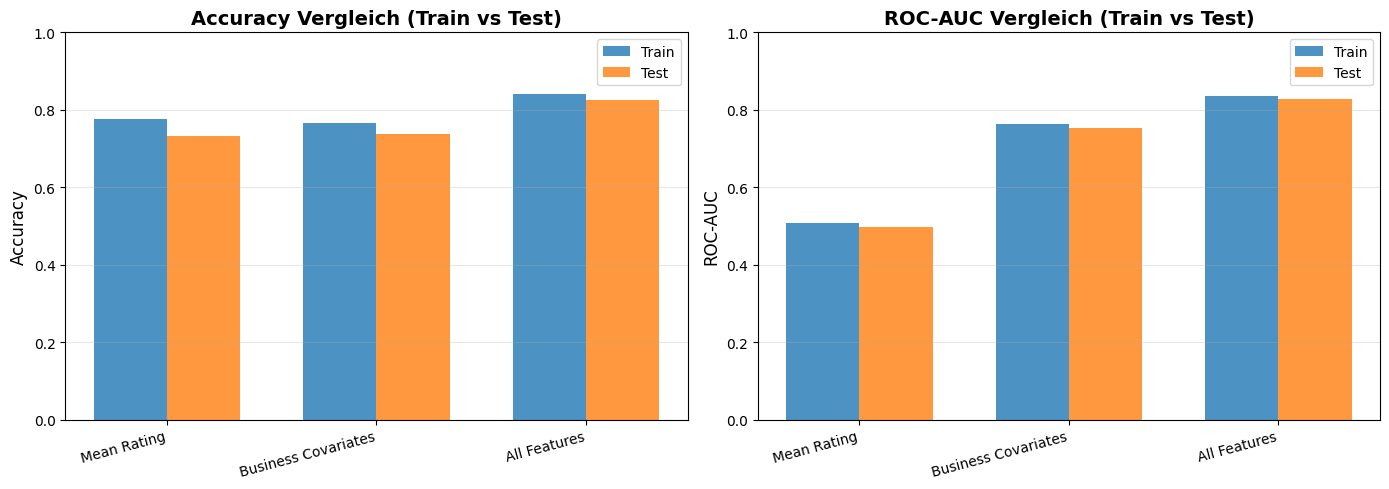


Bestes Modell (Test ROC-AUC): All Features
Test ROC-AUC: 0.8284
Test Accuracy: 0.8242


In [10]:
# Vergleichstabelle erstellen (TEST Performance!)
import pandas as pd

results_comparison = pd.DataFrame(
    {
        "Model": ["Mean Rating", "Business Covariates", "All Features"],
        "Features": [
            "MEAN (1 Variable)",
            f"{len(X_business.columns)} Variablen",
            f"{len(X_all.columns)} Variablen",
        ],
        "Train Accuracy": [
            accuracy_score(y_train, y_pred_mean_train),
            accuracy_score(y_train, y_pred_business_train),
            accuracy_score(y_train, y_pred_all_train),
        ],
        "Test Accuracy": [
            accuracy_score(y_test, y_pred_mean_test),
            accuracy_score(y_test, y_pred_business_test),
            accuracy_score(y_test, y_pred_all_test),
        ],
        "Train ROC-AUC": [
            roc_auc_score(y_train, y_proba_mean_train),
            roc_auc_score(y_train, y_proba_business_train),
            roc_auc_score(y_train, y_proba_all_train),
        ],
        "Test ROC-AUC": [
            roc_auc_score(y_test, y_proba_mean_test),
            roc_auc_score(y_test, y_proba_business_test),
            roc_auc_score(y_test, y_proba_all_test),
        ],
    }
)

print("=" * 80)
print("VERGLEICH DER BENCHMARK-MODELLE")
print("=" * 80)
print(results_comparison.to_string(index=False))

# Visualisierung
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Vergleich
x = np.arange(len(results_comparison))
width = 0.35

axes[0].bar(
    x - width / 2,
    results_comparison["Train Accuracy"],
    width,
    label="Train",
    color="#1f77b4",
    alpha=0.8,
)
axes[0].bar(
    x + width / 2,
    results_comparison["Test Accuracy"],
    width,
    label="Test",
    color="#ff7f0e",
    alpha=0.8,
)
axes[0].set_ylabel("Accuracy", fontsize=12)
axes[0].set_title("Accuracy Vergleich (Train vs Test)", fontsize=14, fontweight="bold")
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_comparison["Model"], rotation=15, ha="right")
axes[0].set_ylim([0, 1])
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# ROC-AUC Vergleich
axes[1].bar(
    x - width / 2,
    results_comparison["Train ROC-AUC"],
    width,
    label="Train",
    color="#1f77b4",
    alpha=0.8,
)
axes[1].bar(
    x + width / 2,
    results_comparison["Test ROC-AUC"],
    width,
    label="Test",
    color="#ff7f0e",
    alpha=0.8,
)
axes[1].set_ylabel("ROC-AUC", fontsize=12)
axes[1].set_title("ROC-AUC Vergleich (Train vs Test)", fontsize=14, fontweight="bold")
axes[1].set_xticks(x)
axes[1].set_xticklabels(results_comparison["Model"], rotation=15, ha="right")
axes[1].set_ylim([0, 1])
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Bestes Modell identifizieren (basierend auf Test ROC-AUC)
best_model_idx = results_comparison["Test ROC-AUC"].idxmax()
print(
    f"\nBestes Modell (Test ROC-AUC): {results_comparison.loc[best_model_idx, 'Model']}"
)
print(f"Test ROC-AUC: {results_comparison.loc[best_model_idx, 'Test ROC-AUC']:.4f}")
print(f"Test Accuracy: {results_comparison.loc[best_model_idx, 'Test Accuracy']:.4f}")